# 06 — H6 arc semantics audit (human review)

Main-couple vs non-couple conflict, and topic × position weights \(W_{tkr}\).
High `4.4` label fidelity ≠ “is it **main-couple** conflict?”

Saved audits + packets only. Rating cells stay blinded; sentence tertiles are visible
because H6 is position-aware.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh
from src.stage11_refined_construct_analysis.analysis import review_display as rd
from src.stage11_refined_construct_analysis.analysis.constructs import normalize_code

ctx = nh.setup("06_h6_arc_semantics_audit")
cfg = ctx.cfg
HYP = "H6"
CODE_COL = "arc_role"

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/06_h6_arc_semantics_audit


## 1. Overview — arc roles with topic labels

In [2]:
master = nh.load_master(cfg)
h6 = master[master[CODE_COL].notna()].copy()
h6["code_norm"] = h6[CODE_COL].map(normalize_code)
print(f"H6-coded topics: {len(h6)}")

overview = rd.annotation_overview(
    h6,
    CODE_COL,
    extra_cols=["main_couple_prob", "non_couple_prob", "unclear_prob"],
)
display(
    overview[
        [
            "topic",
            "taxonomy",
            "code",
            "code_norm",
            "main_couple_prob",
            "non_couple_prob",
        ]
    ]
)
ctx.save_table(overview, "h6_topic_overview_labeled")
display(h6[CODE_COL].value_counts().head(25).to_frame("n"))
display(h6["code_norm"].value_counts(dropna=False).to_frame("n_norm"))

H6-coded topics: 42


,topic,taxonomy,code,code_norm,main_couple_prob,non_couple_prob
0,64 — Confronting A Lifelong Fear,3.2 — Negative Emotions & Distress,"{'protag': ['Alex', 'Jamie'], 'antag': [""Alex'...",None,0.0000,0.0000
1,66 — Paralyzed By Deep-Seated Fear,3.2 — Negative Emotions & Distress,Conflict,ARC_2,0.0000,0.0000
2,92 — Heart Pounding With Dread,3.2 — Negative Emotions & Distress,Conflict,ARC_2,0.0000,0.0000
3,102 — Grief Etched on His Face,3.2 — Negative Emotions & Distress,DISCLOSURE,ARC_4,0.0000,0.0000
4,133 — Holding Back Tears,3.2 — Negative Emotions & Distress,Conflict,ARC_2,0.0000,0.0000
5,145 — Confessing How Much It Hurts,3.2 — Negative Emotions & Distress,Catalyst,ARC_2,0.0000,0.0000
6,152 — Awkward Apology and Embarrassment,3.2 — Negative Emotions & Distress,Conflict,ARC_2,0.0000,0.0000
7,179 — Dreading What You Stand to Lose,3.2 — Negative Emotions & Distress,Conflict,ARC_2,0.8500,0.1000
8,220 — Called Out For Being Embarrassing,3.2 — Negative Emotions & Distress,Complicating Factor,ARC_2,0.0000,0.0000
9,244 — Confessing A Shattered Heart,3.2 — Negative Emotions & Distress,Conflict Resolution,ARC_5,0.0000,0.0000


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/06_h6_arc_semantics_audit/tables/h6_topic_overview_labeled.csv  (42 rows)


,n
arc_role,
Conflict,14
Obstacle,8
REFINED_FALLING,3
OBSTACLE,2
Hidden Information,2
DISCLOSURE,1
"{'protag': ['Alex', 'Jamie'], 'antag': [""Alex's internal struggle"", ""Jamie's job opportunity""], 'mentor': ['Therapist/Counselor'], 'trickster': [""Alex's colleague""], 'herald': [""News of Jamie's job opportunity""]}",1
INTRO,1
Catalyst,1


,n_norm
code_norm,
ARC_2,23
ARC_8,12
None,2
ARC_1,2
ARC_4,1
ARC_0,1
ARC_5,1


## 2. Lexical vs contextual agreement

In [3]:
lex = nh.load_audit_jsonl(cfg, HYP, "A")
ctxu = nh.load_audit_jsonl(cfg, HYP, "B")
adj = nh.load_audit_jsonl(cfg, HYP, "C")
lex_idx = rd.audit_index(lex)
ctx_idx = rd.audit_index(ctxu)
adj_idx = rd.audit_index(adj)

agree = rd.agreement_table(h6, lex_idx, ctx_idx, adj_idx, hyp=HYP)
if not agree.empty:
    print(
        f"Lexical–contextual agreement: {agree['agree'].mean():.1%} "
        f"({int(agree['agree'].sum())}/{len(agree)})"
    )
    ctx.save_table(agree, "h6_lexical_contextual_agreement")
    disagree = agree[~agree["agree"]]
    if len(disagree):
        display(
            disagree[
                ["topic", "taxonomy", "code_a", "code_b", "code_c", "rationale_c"]
            ]
        )

Lexical–contextual agreement: 19.0% (8/42)


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/06_h6_arc_semantics_audit/tables/h6_lexical_contextual_agreement.csv  (42 rows)


,topic,taxonomy,code_a,code_b,code_c,rationale_c
0,3 — Demanding An Explanation,"4.4 — Conflict, Distance & Breakup Threats",UNKNOWN,D,Conflict,
1,24 — Confronting An Unwanted Marriage,"4.4 — Conflict, Distance & Breakup Threats",UNKNOWN,B,ANTAGONIST,
2,37 — Defending A Close Friendship,"4.3 — Secrets, Misunderstandings & Hidden Info...",37,UNKNOWN,Obstacle,
3,43 — Pissed Off and Grumbling,"4.4 — Conflict, Distance & Breakup Threats",UNKNOWN,CELL_D,Conflict,"The topic's taxonomy of 4.4/Conflict, Distance..."
4,64 — Confronting A Lifelong Fear,3.2 — Negative Emotions & Distress,UNKNOWN,C,"{'protag': ['Alex', 'Jamie'], 'antag': [""Alex'...",
5,66 — Paralyzed By Deep-Seated Fear,3.2 — Negative Emotions & Distress,UNKNOWN,Fear,Conflict,
7,92 — Heart Pounding With Dread,3.2 — Negative Emotions & Distress,UNKNOWN,MIDDLE,Conflict,The topic of 'Negative Emotions & Distress' in...
8,94 — Caught in A Lie,"4.3 — Secrets, Misunderstandings & Hidden Info...",UNKNOWN,CONFLICT,REFINED_FALLING,
9,102 — Grief Etched on His Face,3.2 — Negative Emotions & Distress,UNKNOWN,DISCLOSURE,DISCLOSURE,
10,109 — Seeing Past A Guarded Identity,"4.3 — Secrets, Misunderstandings & Hidden Info...",UNKNOWN,IDENTIFICATION,OBSTACLE,


## 3. Main-couple probabilities

Distribution first; then read low-probability topics that still carry conflict / secrecy
arc roles — those are the ones most likely to be external plot, not couple arc.

       main_couple_prob  non_couple_prob  unclear_prob
count           42.0000          42.0000       42.0000
mean             0.0810           0.0095        0.9095
std              0.2525           0.0297        0.2822
min              0.0000           0.0000        0.0500
25%              0.0000           0.0000        1.0000
50%              0.0000           0.0000        1.0000
75%              0.0000           0.0000        1.0000
max              0.8500           0.1000        1.0000


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/06_h6_arc_semantics_audit/figures/h6_main_couple_hist.png


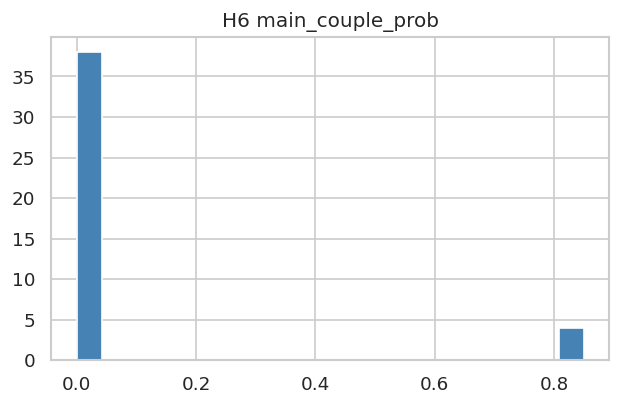

Topics with main_couple_prob < 0.4: 38


,topic,taxonomy,code,code_norm,main_couple_prob
0,64 — Confronting A Lifelong Fear,3.2 — Negative Emotions & Distress,"{'protag': ['Alex', 'Jamie'], 'antag': [""Alex'...",None,0.0000
1,66 — Paralyzed By Deep-Seated Fear,3.2 — Negative Emotions & Distress,Conflict,ARC_2,0.0000
2,92 — Heart Pounding With Dread,3.2 — Negative Emotions & Distress,Conflict,ARC_2,0.0000
3,102 — Grief Etched on His Face,3.2 — Negative Emotions & Distress,DISCLOSURE,ARC_4,0.0000
4,133 — Holding Back Tears,3.2 — Negative Emotions & Distress,Conflict,ARC_2,0.0000
5,145 — Confessing How Much It Hurts,3.2 — Negative Emotions & Distress,Catalyst,ARC_2,0.0000
6,152 — Awkward Apology and Embarrassment,3.2 — Negative Emotions & Distress,Conflict,ARC_2,0.0000
7,220 — Called Out For Being Embarrassing,3.2 — Negative Emotions & Distress,Complicating Factor,ARC_2,0.0000
8,244 — Confessing A Shattered Heart,3.2 — Negative Emotions & Distress,Conflict Resolution,ARC_5,0.0000
9,281 — Told to Calm Down First,3.2 — Negative Emotions & Distress,Conflict,ARC_2,0.0000


In [4]:
print(h6[["main_couple_prob", "non_couple_prob", "unclear_prob"]].describe())
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(h6["main_couple_prob"].dropna(), bins=20, color="steelblue", edgecolor="white")
ax.set_title("H6 main_couple_prob")
ctx.save_figure(fig, "h6_main_couple_hist")
plt.show()

low_mc = h6[h6["main_couple_prob"].fillna(0) < 0.4].copy()
print(f"Topics with main_couple_prob < 0.4: {len(low_mc)}")
if len(low_mc):
    display(
        rd.annotation_overview(low_mc, CODE_COL, extra_cols=["main_couple_prob"])[
            ["topic", "taxonomy", "code", "code_norm", "main_couple_prob"]
        ]
    )

## 4. Topic × position weights \(W_{tkr}\)

In [5]:
wtkr = nh.load_w_tkr(cfg)
print(f"W_tkr rows: {len(wtkr)}")
if not wtkr.empty:
    wtkr = wtkr.copy()
    wtkr["code_norm"] = wtkr["construct_code"].map(normalize_code)
    display(
        wtkr.groupby(["tertile", "code_norm"], dropna=False)["weight"]
        .mean()
        .unstack(fill_value=0)
        .round(3)
    )
    ctx.save_table(wtkr, "w_tkr_raw")

W_tkr rows: 92


code_norm,ARC_2,NaN
tertile,,
BEGIN,0.0000,0.2330
END,0.0000,0.2000
MIDDLE,0.0000,0.0670
begin,0.5000,0.4240
end,0.4500,0.5590
middle,0.5700,0.4590


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/06_h6_arc_semantics_audit/tables/w_tkr_raw.csv  (92 rows)


## 5. Close reading

Force-include low main-couple topics. In the cards, watch tertile tags on sentences:
rising end-conflict that is non-couple should not feed REFINED_RISING the same way
main-couple conflict does.

In [6]:
review_ids = rd.select_review_topics(
    h6,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    force_ids=low_mc["topic_id"].tolist(),
    per_code=3,
    seed=42,
)
packs = rd.show_review_set(
    cfg,
    h6,
    review_ids,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    code_col=CODE_COL,
    max_sentences=10,
)
ctx.save_markdown(
    rd.render_review_markdown(packs, title="H6 arc semantics — close-reading pack"),
    "close_reading_pack",
)
ctx.save_table(
    h6[
        [
            "topic_id",
            "current_topic_label",
            "current_taxonomy_id",
            "current_taxonomy_name",
            "arc_role",
            "code_norm",
            "main_couple_prob",
            "non_couple_prob",
        ]
    ],
    "arc_topic_annotations",
)

Close-reading 42 of 42 topics (disagreements / mixed / manual / stratified sample).

  TOPIC 37 — Defending A Close Friendship
  Taxonomy : 4.3 — Secrets, Misunderstandings & Hidden Information
  Code     : Obstacle  (norm: ARC_8)
  Stage08 snippets:
      · i've told you -- we're just good friends.
      · and i’ll grant ye i’ve been a bad friend to you.
      · but we’ve been friends for a long time.
  Novel sentences:
    · [BOOK_002, CELL_D, tertile=middle, p=0.63]
        Good, then get out of my face and give me a minute with my friend.”
    · [BOOK_002, CELL_D, tertile=middle, p=0.47]
        He didn’t have any life-long friends, with the exception of Butch.
    · [BOOK_002, CELL_D, tertile=end, p=0.46]
        A friend once told me it’s okay to lean on someone,” he said. “
  Pass A/B/C:
    A lexical: 37
        The main-couple filter focuses on the relationship dynamics between the main
        characters, excluding external conflicts related to fidelity. The narrative arc
   

  TOPIC 272 — Silence Held Until Arrival
  Taxonomy : 4.3 — Secrets, Misunderstandings & Hidden Information
  Code     : Obstacle  (norm: ARC_8)
  Stage08 snippets:
      · she didn’t speak a word until they got to their destination.
      · the high priestess had said very little to her in the day and a half leading up to
      · her departure.
      · he should’ve known better than to think brenna would be content with the
      · noncommittal answer he’d given her.
  Novel sentences:
    · [BOOK_002, CELL_B, tertile=end, p=0.68]
        She was going to the hospital, and this time, she would not take no for an answer.
  Pass A/B/C:
    A lexical: UNKNOWN
    B contextual: Conflict
        Out of the 16 sentences, 10 involve the main couple, either in conflict or
        avoidance. The dominant code is 'Conflict', with 8 out of 16 sentences showing
        conflict between the main couple.
    C adjudicate: Obstacle

  TOPIC 281 — Told to Calm Down First
  Taxonomy : 3.2 — Negative E

  saved markdown: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/06_h6_arc_semantics_audit/tables/close_reading_pack.md
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/06_h6_arc_semantics_audit/tables/arc_topic_annotations.csv  (42 rows)


Later: REFINED_FALLING / REFINED_RISING deltas and RARC; EXTERNAL_PLOT_CONFLICT kept
outside the arc equation.

print("H6 audit review complete.")